This notebook reproduces Figure 2 in "Humidity’s role in population heat-health risk" by Kong et al.

In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import geopandas as gpd
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# Nature Communications artwork requirements:
# - sans-serif font, preferably Helvetica/Arial (Liberation Sans is metrically
#   identical to Arial and available on this system; falls back to Arial/DejaVu
#   Sans if Liberation Sans is unavailable elsewhere)
# - text between 5-7 pt at final print size
# - vector PDF with true (editable) embedded fonts, not the Type 3 fonts
#   matplotlib embeds by default
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42

# matplotlib renders math text ($...$, e.g. beta, GHSI_in, 10^3) with a separate
# 'mathtext' font that ignores font.family by default (falls back to DejaVu Sans) --
# point it at the same Liberation Sans family so math and regular text match
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Liberation Sans'
plt.rcParams['mathtext.it'] = 'Liberation Sans:italic'
plt.rcParams['mathtext.bf'] = 'Liberation Sans:bold'


In [2]:
# read in mean absolute prediction error of GHSI
mae=xr.open_dataset('../data/GHSI_MAE.nc').MAE
"""
MAE of daily heatstroke prediction at each prefecture (dim: pf);
Conditional on a wide range of humidity weight (dim: beta);
For both outdoor and indoor versions (dim: exposure) of General Heat Stress Index (GHSI);
MAE is calculated as an average across the validation periods of 10-fold cross validation
"""
mae

<xarray.DataArray 'MAE' (pf: 47, exposure: 2, beta: 2451)> Size: 2MB
[230394 values with dtype=float64]
Coordinates:
  * pf        (pf) int64 376B 1 2 3 4 5 6 7 8 9 ... 39 40 41 42 43 44 45 46 47
  * exposure  (exposure) <U7 56B 'outdoor' 'indoor'
  * beta      (beta) float64 20kB -8.0 -7.99 -7.98 -7.97 ... 16.48 16.49 16.5
Attributes:
    long_name:  Mean absolute error (MAE) of daily heatstroke prediction at e...

In [3]:
mae=mae*122/1000 # scale daily MAE to summer total in 10^3
Tokyo=mae.sel(pf=13) # select Tokyo with prefecture index=13
Osaka=mae.sel(pf=27) # select Osaka with prefecture index=27

In [4]:
# determine optimal humidity weight (beta) with lowest MAE for each prefecture
optimal_beta_prefecture=mae.idxmin(dim='beta')
# determine optimal humidity weight (beta) with lowest MAE at country level
optimal_beta_country=mae.mean('pf').idxmin('beta')

In [5]:
# calculate lowest MAE of heatstroke prediction at each prefecture across a wide range of beta
lowest_mae_prefecture=mae.min('beta')
# calculate lowest MAE of heatstroke prediction at country level across a wide range of beta
lowest_mae_country=mae.mean('pf').min('beta')

In [6]:
# Load Japan prefecture boundaries from Natural Earth (1:10m admin-1 states/provinces),
# fetched via cartopy's built-in downloader; iso_3166_2 codes (JP-01..JP-47) align directly
# with the prefecture index (pf) used throughout this analysis, avoiding a dependency on a
# third-party GitHub mirror of GSI's Global Map Japan data
import cartopy.io.shapereader as shpreader

ne_path = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_1_states_provinces')
gdf = gpd.read_file(ne_path)
gdf = gdf[gdf['admin'] == 'Japan'].copy()
gdf['id'] = gdf['iso_3166_2'].str.replace('JP-', '', regex=False).astype(int)
gdf = gdf.sort_values('id').reset_index(drop=True)

# add a column to gdf representing optimal beta of each prefecture based on outdoor version of GHSI
tmp=[]
for k in range(47):
    index=gdf.id[k]
    tmp.append(optimal_beta_prefecture.sel(exposure='outdoor').sel(pf=index).values.item())
gdf['outdoor']=tmp

# add a column to gdf representing optimal beta of each prefecture based on indoor version of GHSI
tmp=[]
for k in range(47):
    index=gdf.id[k]
    tmp.append(optimal_beta_prefecture.sel(exposure='indoor').sel(pf=index).values.item())
gdf['indoor']=tmp


/home/kong97/.conda/envs/geo_env/lib/python3.1/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/home/kong97/.conda/envs/geo_env/lib/python3.1/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/home/kong97/.conda/envs/geo_env/lib/python3.1/site-packages/xarray/core/dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will chan

findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


Text(0.5, 1, '$\\mathrm{GHSI}_{\\mathrm{in}}$')

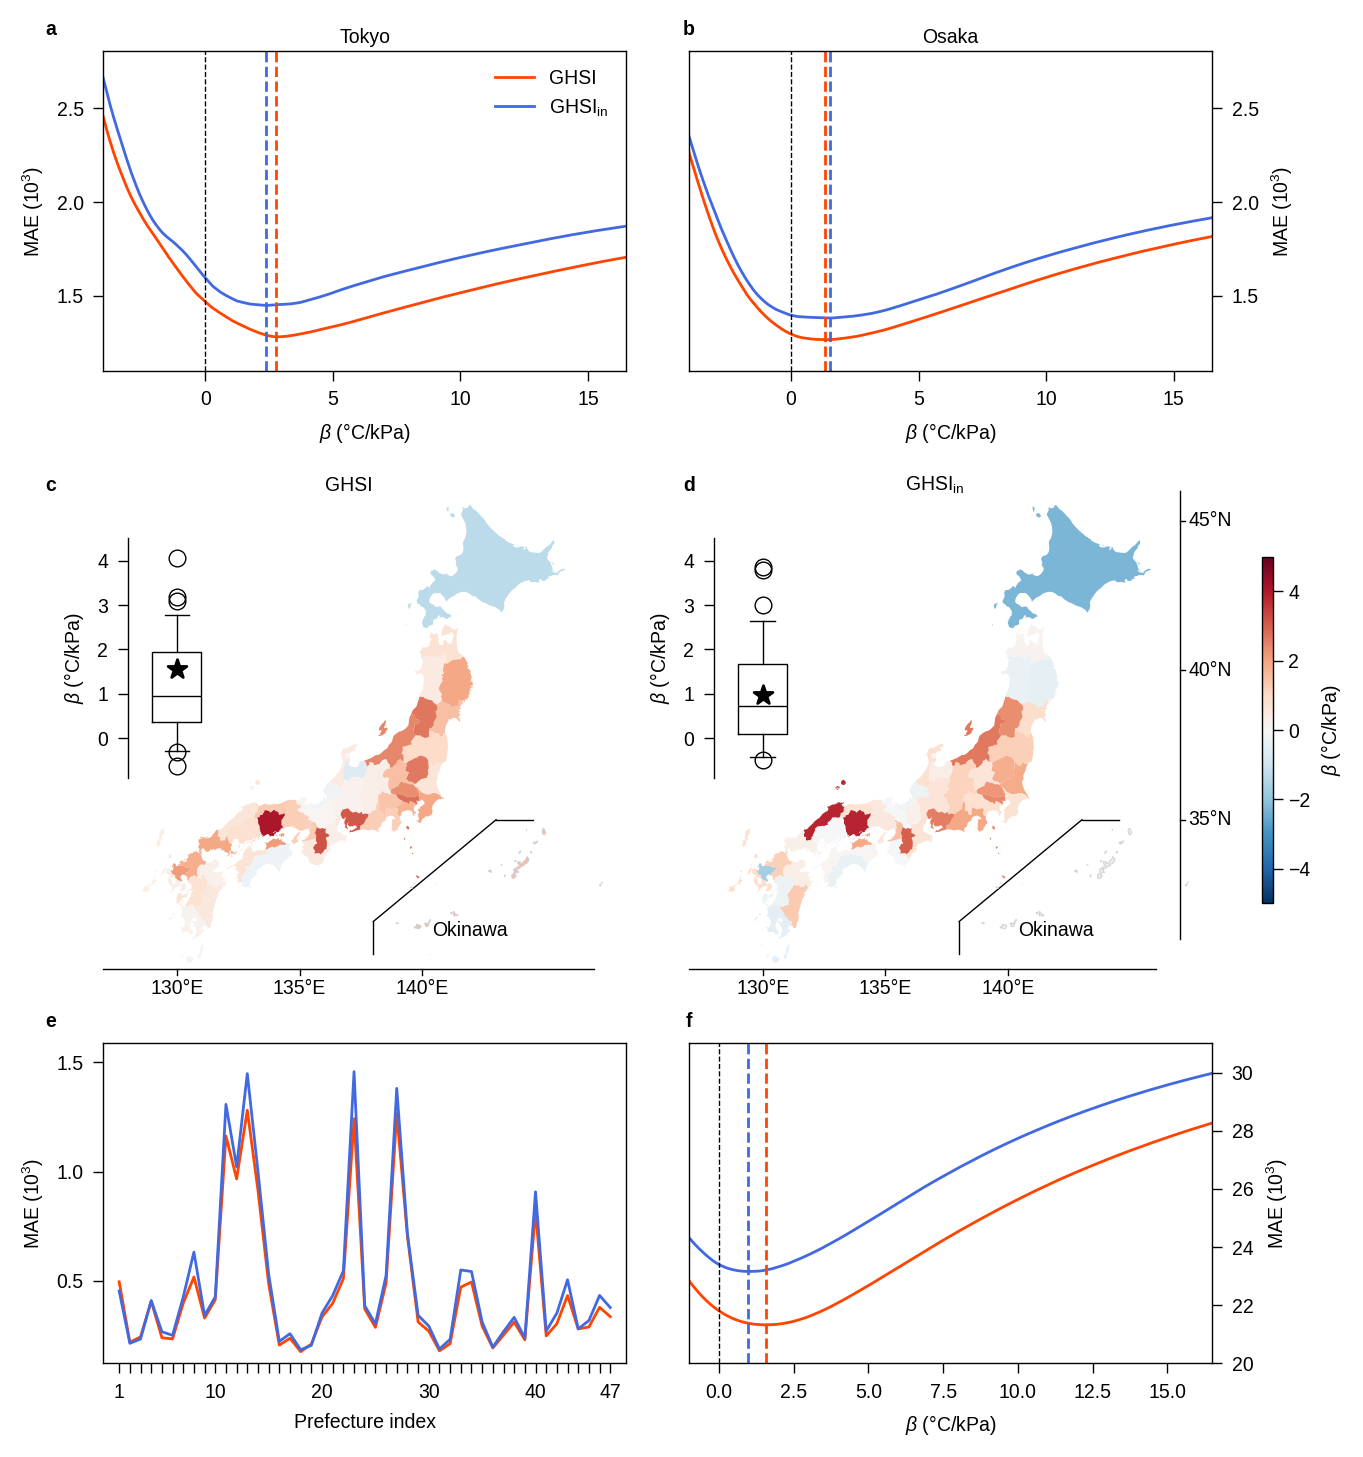

In [7]:
tick_size=7
label_size=7
annote_size=7

red='orangered'
blue = 'royalblue'

# subplot for panel a and b
def subplot1(ax,x,y1,y2,title):
    p=ax.plot(x,y1,linewidth=1,color=red,label='GHSI')
    p=ax.plot(x,y2,linewidth=1,color=blue,label=r'$\mathrm{GHSI}_{\mathrm{in}}$')
    ax.set_xlabel(r'$\beta$ (°C/kPa)',fontsize=label_size)
    ax.set_ylabel('MAE '+ '('+r'$\mathrm{10}^{\mathrm{3}}$'+')',fontsize=label_size)
    ax.tick_params(axis='both', labelsize=tick_size)
    ax.set_title(title,fontsize=label_size, pad=3)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
    ax.axvline(x=x[y1.argmin().values.item()],color=red,linestyle='--', linewidth=1)
    ax.axvline(x=x[y2.argmin().values.item()],color=blue,linestyle='--', linewidth=1)
    ax.set_xlim(-4,16.5)
    return p

# subplot for panel e and f (same style)
def subplot2(ax,x,y1,y2):
    p=ax.plot(x,y1,linewidth=1,color=red,label='GHSI')
    p=ax.plot(x,y2,linewidth=1,color=blue,label=r'$\mathrm{GHSI}_{\mathrm{in}}$')
    ax.set_xlabel('Prefecture index',fontsize=label_size)
    ax.set_ylabel('MAE '+ '('+r'$\mathrm{10}^{\mathrm{3}}$'+')',fontsize=label_size)
    ax.tick_params(axis='both', labelsize=tick_size)
    return p

fig = plt.figure(figsize=(7.087, 7.214))  # 180 x 183 mm: content-fit height (well under
                                           # NC's 210 mm cap), width fixed at the 2-column max

gs = gridspec.GridSpec(6, 7,
                       height_ratios=[1.6, 0.598, 2.394, 0.370, 1.6, 0.386],
                       width_ratios=[0.2, 1, 0.01, 0.1, 0.01, 1, 0.2],
                       hspace=0, wspace=0,
                       left=0.035, right=0.965, top=0.9697, bottom=0.0065)
                       # fill ~180 mm canvas width; top/bottom reclaim matplotlib's large default
                       # margins so a/b, e/f can stay tall without shrinking the map row

ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 5])
ax3 = fig.add_subplot(gs[2, 0:3])
ax4 = fig.add_subplot(gs[2, 4:])
ax5 = fig.add_subplot(gs[4, 1])
ax6 = fig.add_subplot(gs[4, 5])

# ── panel a ──
subplot1(ax1, Tokyo.beta.values,
         Tokyo.sel(exposure='outdoor'),
         Tokyo.sel(exposure='indoor'), 'Tokyo')
ax1.legend(fontsize=7, frameon=False)
ax1.set_ylim(9*122/1000, 23*122/1000)
ax1.set_yticks([1.5, 2, 2.5])

# ── panel b: yticks and label on the right ──
subplot1(ax2, Osaka.beta.values,
         Osaka.sel(exposure='outdoor'),
         Osaka.sel(exposure='indoor'), 'Osaka')
ax2.set_ylim(9*122/1000, 23*122/1000)
ax2.set_yticks([1.5, 2, 2.5])
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()

# ── panels c and d: maps ──
cmap = 'RdBu_r'
norm = colors.Normalize(vmin=-5, vmax=5)
mainland_extent = [127, 147, 30, 46]
okinawa_extent  = [122, 132, 23, 28]

def add_corner_marks(ax, extent, lon_ticks, lat_ticks, tick_len=0.25, label_gap=0.2,
                      corner_gap=1.0, fontsize=7, show_lat=True):
    """Longitude marked by a line along the bottom of the map; latitude (optional) marked
    by a line along the right, ticks pointing outward. The two lines stop short of the
    corner so they don't touch."""
    x0, x1, y0, y1 = extent
    # bottom line: longitude, ticks pointing outward (down); stops short of the right edge
    ax.plot([x0, x1 - corner_gap if show_lat else x1], [y0, y0], color='black', linewidth=0.5,
            clip_on=False, zorder=5)
    for lon in lon_ticks:
        ax.plot([lon, lon], [y0 - tick_len, y0], color='black', linewidth=0.5, clip_on=False, zorder=5)
        ax.text(lon, y0 - tick_len - label_gap, f'{lon}\N{DEGREE SIGN}E', ha='center', va='top',
                fontsize=fontsize, clip_on=False)
    if not show_lat:
        return
    # right line: latitude, ticks pointing outward (right); stops short of the bottom edge
    ax.plot([x1, x1], [y0 + corner_gap, y1], color='black', linewidth=0.5, clip_on=False, zorder=5)
    for lat in lat_ticks:
        ax.plot([x1, x1 + tick_len], [lat, lat], color='black', linewidth=0.5, clip_on=False, zorder=5)
        ax.text(x1 + tick_len + label_gap, lat, f'{lat}\N{DEGREE SIGN}N', ha='left', va='center',
                fontsize=fontsize, clip_on=False)

# pass 1: plot + let the aspect-driven box shrink resolve, for BOTH maps first
for ax, col in zip([ax3, ax4], ['outdoor', 'indoor']):
    gdf.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             edgecolor='lightgrey', linewidth=0, legend=False,
             missing_kwds={"color": "lightgrey", "label": "No data"})
    ax.set_xlim(mainland_extent[0], mainland_extent[1])
    ax.set_ylim(mainland_extent[2], mainland_extent[3])
fig.canvas.draw()

# pass 3: everything else (corner marks, Okinawa inset, leader line) now that final
# positions are set
for ax, col, show_lat in zip([ax3, ax4], ['outdoor', 'indoor'], [False, True]):
    ax.axis('off')
    add_corner_marks(ax, mainland_extent, lon_ticks=[130, 135, 140], lat_ticks=[35, 40, 45],
                      tick_len=0.18, label_gap=0.15, fontsize=tick_size, show_lat=show_lat)

    ax_inset = inset_axes(ax, width="50%", height="31.25%", loc='lower left',
                          bbox_to_anchor=(0.55, 0, 1, 1),
                          bbox_transform=ax.transAxes, borderpad=0)
    gdf[gdf["id"] == 47].plot(column=col, ax=ax_inset, cmap=cmap, norm=norm,
             edgecolor='lightgrey', linewidth=0.4, legend=False,
             missing_kwds={"color": "lightgrey", "label": "No data"})
    ax_inset.set_xlim(okinawa_extent[0], okinawa_extent[1])
    ax_inset.set_ylim(okinawa_extent[2], okinawa_extent[3])
    ax_inset.axis('off')

    ax.plot([143, 144.5], [35, 35], c='k', linewidth=0.5)
    ax.plot([138, 138], [30.5, 31.6], c='k', linewidth=0.5)
    ax.plot([138, 143], [31.6, 35], c='k', linewidth=0.5)
    ax_inset.text(124.4, 24.0, 'Okinawa', fontsize=label_size)

# ── colorbar ──
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(norm=Normalize(vmin=-5, vmax=5), cmap='RdBu_r')
sm.set_array(np.linspace(-5, 5, 100))
cbar = fig.colorbar(sm, ax=[ax3, ax4], orientation='vertical', pad=0.11,
                    fraction=0.11, aspect=32, shrink=0.68)
cbar.set_label(r'$\beta$ (°C/kPa)', fontsize=label_size, labelpad=3)
cbar.ax.tick_params(labelsize=tick_size, pad=2, width=0.5, which='both')
cbar.outline.set_linewidth(0.5)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.5)
for t in cbar.ax.yaxis.get_major_ticks() + cbar.ax.yaxis.get_minor_ticks():
    t.tick1line.set_linewidth(0.5)
    t.tick2line.set_linewidth(0.5)

# reposition both maps so their left edge lines up with a/b -- done LAST because
# fig.colorbar(ax=[ax3, ax4]) reshrinks/moves ax3/ax4 itself to make room for the
# colorbar, which would otherwise undo this alignment (set_anchor has no effect here;
# geopandas' plot uses a box-aspect path that ignores it, confirmed by an anchor sweep)
fig.canvas.draw()
for ax, ref_ax in [(ax3, ax1), (ax4, ax2)]:
    pos = ax.get_position()
    delta_x = ref_ax.get_position().x0 - pos.x0
    ax.set_position([pos.x0 + delta_x, pos.y0, pos.width, pos.height])

# place the colorbar explicitly: a bit wider and longer than its fig.colorbar() default,
# positioned with enough clearance from ax4's new (right-shifted) edge on one side and
# from the page's right margin on the other (for its tick numbers + rotated axis label)
cpos = cbar.ax.get_position()
cbar_width = 0.013
cbar_height = 0.24
cbar_x0 = ax4.get_position().x1 + 0.058  # clear panel d's outward 45/40/35N tick labels
cbar_y0 = (cpos.y0 + cpos.y1) / 2 - cbar_height / 2
cbar.ax.set_position([cbar_x0, cbar_y0, cbar_width, cbar_height])

# ── box plot inset for panel c ──
ax_inset3 = inset_axes(ax3, width="50%", height="50%", loc='lower left',
                        bbox_to_anchor=(0.05, 0.4, 1, 1),
                        bbox_transform=ax3.transAxes, borderpad=0)  # was `ax.transAxes` (leftover
                                                                    # loop variable = ax4): both
                                                                    # insets were anchored to ax4,
                                                                    # not their own parent axes
ax_inset3.boxplot(optimal_beta_prefecture.sel(exposure='outdoor'),
                  whis=(5,95), widths=0.1, positions=[0],
                  boxprops=dict(linewidth=0.5),
                  whiskerprops=dict(linewidth=0.5),
                  capprops=dict(linewidth=0.5),
                  medianprops=dict(color="black", linewidth=0.5),
                  flierprops=dict(markeredgewidth=0.5, linewidth=0.5))
ax_inset3.spines['top'].set_visible(False)
ax_inset3.spines['right'].set_visible(False)
ax_inset3.spines['bottom'].set_visible(False)
ax_inset3.set_xticks([]); ax_inset3.set_xticklabels([])
ax_inset3.set_xlim(-0.1, 0.4)
ax_inset3.set_ylim(-0.9, 4.5)
ax_inset3.set_yticks([0,1,2,3,4])
ax_inset3.tick_params(axis='both', labelsize=tick_size, width=0.5)
ax_inset3.spines['left'].set_linewidth(0.5)
ax_inset3.set_facecolor("none"); ax_inset3.patch.set_alpha(0)
ax_inset3.scatter(0, optimal_beta_country.sel(exposure='outdoor'), marker='*', c='k', s=50)
ax_inset3.set_ylabel(r'$\beta$ (°C/kPa)', fontsize=label_size)

# ── box plot inset for panel d ──
ax_inset4 = inset_axes(ax4, width="50%", height="50%", loc='lower left',
                        bbox_to_anchor=(0.05, 0.4, 1, 1),
                        bbox_transform=ax4.transAxes, borderpad=0)
ax_inset4.boxplot(optimal_beta_prefecture.sel(exposure='indoor'),
                  whis=(5,95), widths=0.1, positions=[0],
                  boxprops=dict(linewidth=0.5),
                  whiskerprops=dict(linewidth=0.5),
                  capprops=dict(linewidth=0.5),
                  medianprops=dict(color="black", linewidth=0.5),
                  flierprops=dict(markeredgewidth=0.5, linewidth=0.5))
ax_inset4.spines['top'].set_visible(False)
ax_inset4.spines['right'].set_visible(False)
ax_inset4.spines['bottom'].set_visible(False)
ax_inset4.set_xticks([]); ax_inset4.set_xticklabels([])
ax_inset4.set_xlim(-0.1, 0.4)
ax_inset4.set_ylim(-0.9, 4.5)
ax_inset4.set_yticks([0,1,2,3,4])
ax_inset4.tick_params(axis='both', labelsize=tick_size, width=0.5)
ax_inset4.spines['left'].set_linewidth(0.5)
ax_inset4.set_facecolor("none"); ax_inset4.patch.set_alpha(0)
ax_inset4.scatter(0, optimal_beta_country.sel(exposure='indoor'), marker='*', c='k', s=50)
ax_inset4.set_ylabel(r'$\beta$ (°C/kPa)', fontsize=label_size)

# ── panel e ──
subplot2(ax5, np.arange(1,48),
         lowest_mae_prefecture.sel(exposure='outdoor'),
         lowest_mae_prefecture.sel(exposure='indoor'))
ax5.set_xticks(np.arange(1,48))
ax5.set_xticklabels([str(i) if i in [1,10,20,30,40,47] else '' for i in range(1,48)])
ax5.set_xlim(-0.5, 48.5)
ax5.set_ylim(1*122/1000, 13*122/1000)
ax5.set_yticks([0.5, 1, 1.5])

# ── panel f: yticks and label on the right ──
X = mae.sel(exposure='indoor').sum('pf').sel(beta=slice(-4, 16.5))['beta'].values
ax6.plot(X, mae.sel(exposure='indoor').sum('pf').sel(beta=slice(-4, 16.5)),
         zorder=0, c=blue, linewidth=1, label=r'$\mathrm{GHSI}_{\mathrm{in}}$')
ax6.plot(X, mae.sel(exposure='outdoor').sum('pf').sel(beta=slice(-4, 16.5)),
         zorder=0, c=red, linewidth=1, label='GHSI')
ax6.tick_params(axis='both', labelsize=tick_size)
ax6.set_xlim(-1, 16.5)
ax6.set_ylabel('MAE '+ '('+r'$\mathrm{10}^{\mathrm{3}}$'+')', fontsize=label_size)
ax6.yaxis.set_label_position('right')
ax6.yaxis.tick_right()
ax6.set_xlabel(r'$\beta$ (°C/kPa)', fontsize=label_size)
ax6.vlines(0, 20, 32, color='black', linewidth=0.5, linestyle='dashed', zorder=0)
ax6.vlines(mae.sel(exposure='indoor').sum('pf').idxmin().values.item(),
           20, 32, color=blue, linewidth=1, linestyle='dashed', zorder=0)
ax6.vlines(mae.sel(exposure='outdoor').sum('pf').idxmin().values.item(),
           20, 32, color=red, linewidth=1, linestyle='dashed', zorder=0)
ax6.set_ylim(20, 31)
ax6.set_yticks([20,22,24,26,28,30])

for ax in [ax1, ax2, ax5, ax6]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

# ── annotations ──
# a,c,e (and b,d,f) must sit at the same absolute horizontal position in the figure, even
# though ax3/ax4 (the maps) span 3 grid columns and are much wider than ax1/ax2/ax5/ax6 --
# an axes-fraction x that looks right on the narrow axes lands somewhere else on the wide
# ones. Convert a single figure-fraction x per column into each axes' own fraction instead.
def x_in_axes_fraction(ref_ax, ref_x_frac, target_ax):
    fig_x = ref_ax.get_position().x0 + ref_x_frac * ref_ax.get_position().width
    tgt_pos = target_ax.get_position()
    return (fig_x - tgt_pos.x0) / tgt_pos.width

col1_x = -0.1  # anchor: same value already used for ax1 (panel a)
col2_x = 0.0   # anchor: same value already used for ax2 (panel b)

anno_opts = dict(xy=(col1_x, 1.05), xycoords='axes fraction', va='baseline', ha='center')
ax1.annotate('a', **anno_opts, fontsize=annote_size, fontweight='bold')
anno_opts = dict(xy=(col2_x, 1.05), xycoords='axes fraction', va='baseline', ha='center')
ax2.annotate('b', **anno_opts, fontsize=annote_size, fontweight='bold')

anno_opts = dict(xy=(x_in_axes_fraction(ax1, col1_x, ax3), 1), xycoords='axes fraction',
                  va='baseline', ha='center')
ax3.annotate('c', **anno_opts, fontsize=annote_size, fontweight='bold')
anno_opts = dict(xy=(x_in_axes_fraction(ax2, col2_x, ax4), 1), xycoords='axes fraction',
                  va='baseline', ha='center')
ax4.annotate('d', **anno_opts, fontsize=annote_size, fontweight='bold')

anno_opts = dict(xy=(x_in_axes_fraction(ax1, col1_x, ax5), 1.05), xycoords='axes fraction',
                  va='baseline', ha='center')
ax5.annotate('e', **anno_opts, fontsize=annote_size, fontweight='bold')
anno_opts = dict(xy=(x_in_axes_fraction(ax2, col2_x, ax6), 1.05), xycoords='axes fraction',
                  va='baseline', ha='center')
ax6.annotate('f', **anno_opts, fontsize=annote_size, fontweight='bold')

anno_opts = dict(xy=(0.5, 1), xycoords='axes fraction', va='baseline', ha='center')
ax3.annotate('GHSI', **anno_opts, fontsize=label_size)
ax4.annotate(r'$\mathrm{GHSI}_{\mathrm{in}}$', **anno_opts, fontsize=label_size)

In [8]:
out_dir = './'
fig.savefig(f'{out_dir}/Figure2.pdf', bbox_inches=None)
print('Figure size (mm):', fig.get_size_inches()*25.4)


Figure size (mm): [180.0098 183.2356]


**Figure 2**: Identification of optimal $\beta$ values. (a,b) Summer cumulative mean absolute error (MAE) of prediction on daily heatstroke-related emergency ambulance dispatches in Tokyo and Osaka based on the General Heat Stress Index (GHSI) and its indoor formulation (GHSI$_{\mathrm{in}}$) across a range of $\beta$ values. Thick dashed vertical lines indicate the optimal $\beta$ values that minimize MAE. (c,d) Spatial distribution of optimal $\beta$ for GHSI and GHSI$_{\mathrm{in}}$ in Japan. Insets summarize the distribution of optimal $\beta$ across 47 prefectures (boxes: interquartile range; whiskers: 5th--95th percentiles; horizontal line: median). The black star denotes the national-level optimal $\beta$ that minimizes total MAE across all prefectures. (e) Summer cumulative MAE for GHSI and GHSI$_{\mathrm{in}}$ in each prefecture, conditioned on their prefecture-specific optimal $\beta$. (f) Same as (a) and (b) but at national level. Prefecture boundaries in c,d are from Natural Earth (https://www.naturalearthdata.com), 1:10m Cultural Vectors, Admin 1 - States, Provinces.